# 🎓 ConvoEase — Fine-Tuning Phi-3-mini for Text Moderation
### QLoRA Fine-Tuning with Unsloth | Google Colab T4 GPU

---

## 📋 Before You Start — Read This

| Item | Detail |
|---|---|
| **Model** | `microsoft/Phi-3-mini-4k-instruct` (3.8B params) |
| **Method** | QLoRA — fine-tunes only adapter weights (saves VRAM & time) |
| **GPU needed** | T4 (free Colab) — 16GB VRAM, uses ~6GB |
| **Dataset (2000 rows, 3 epochs)** | ⏱ ~50–70 minutes |
| **Dataset (5000 rows, 3 epochs)** | ⏱ ~2–2.5 hours |
| **Dataset (10,841 rows, 3 epochs)** | ⏱ ~4–5 hours ❌ (Colab disconnects) |

> **Recommendation: use 2000 rows.** You get real training metrics, real loss curves,  
> real confusion matrix — everything examiners want — in under 70 minutes.

---

## 📁 Setup Checklist
1. **Runtime → Change runtime type → T4 GPU** ← do this first
2. Upload `convoease_full_dataset.csv` to your Google Drive
3. Run cells top to bottom


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## ✅ Step 1 — Verify GPU

In [3]:
import subprocess, sys

result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "⚠️  No GPU found. Go to Runtime → Change runtime type → T4 GPU")


Fri Apr  3 07:20:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 📦 Step 2 — Install Libraries
> Takes 2–3 minutes on first run

In [4]:
%%capture
# Unsloth: makes QLoRA training 2× faster + handles quantization automatically
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes
!pip install matplotlib seaborn scikit-learn pandas tabulate
print("✅ Installation complete")


## 📥 Step 3 — Imports

In [13]:
from unsloth import FastLanguageModel # Moved to top to ensure patching occurs

import os, json, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
from IPython.display import display, HTML

import torch
from datasets import Dataset
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.model_selection import train_test_split
from transformers import TrainingArguments
from trl import SFTTrainer

warnings.filterwarnings("ignore")

# Set plot style globally
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor":   "#1a1a2e",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "white",
    "text.color":       "white",
    "xtick.color":      "white",
    "ytick.color":      "white",
    "grid.color":       "#333",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "font.family":      "monospace",
})

ACCENT  = "#7c3aed"   # violet — matches ConvoEase theme
ACCENT2 = "#06b6d4"   # cyan
GREEN   = "#10b981"
RED     = "#ef4444"
YELLOW  = "#f59e0b"

print("✅ All imports successful")
print(f"🔥 PyTorch: {torch.__version__}")
print(f"🔥 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🔥 GPU: {torch.cuda.get_device_name(0)}")
    print(f"🔥 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ All imports successful
🔥 PyTorch: 2.10.0+cu128
🔥 CUDA available: True
🔥 GPU: Tesla T4
🔥 VRAM: 15.6 GB


## ⚙️ Step 4 — Configuration
> **Adjust `DATASET_ROWS` here if needed**

In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# CONFIGURATION — edit these values
# ──────────────────────────────────────────────────────────────────────────────

DATASET_CSV   = "/content/drive/MyDrive/Projects/Drive Project Backups/Datasets/convoease_full_dataset.csv"  # path in Drive
DATASET_ROWS  = 2000          # rows to use — 2000 → ~60 min | 5000 → ~2 hrs
TEST_SPLIT    = 0.15          # 15% held out for evaluation
RANDOM_SEED   = 42

# Model
MODEL_NAME    = "unsloth/Phi-3-mini-4k-instruct"   # 3.8B, fits T4 with QLoRA
MAX_SEQ_LEN   = 512           # token limit per example
LOAD_IN_4BIT  = True          # 4-bit quantization — saves VRAM

# LoRA adapter settings (what actually gets trained)
LORA_R        = 16            # adapter rank
LORA_ALPHA    = 32            # scaling factor
LORA_DROPOUT  = 0.05

# Training
BATCH_SIZE    = 4             # per device
GRAD_ACCUM    = 4             # effective batch = 4 × 4 = 16
LEARNING_RATE = 2e-4
NUM_EPOCHS    = 3
WARMUP_RATIO  = 0.1
LR_SCHEDULER  = "cosine"

# Output
OUTPUT_DIR    = "/content/convoease_model"
DRIVE_SAVE    = "/content/drive/MyDrive/convoease_finetuned_model"

# ──────────────────────────────────────────────────────────────────────────────
# Derived
STEPS_PER_EPOCH_APPROX = int(DATASET_ROWS * (1 - TEST_SPLIT) / (BATCH_SIZE * GRAD_ACCUM))
TOTAL_STEPS = STEPS_PER_EPOCH_APPROX * NUM_EPOCHS

print("╔══════════════════════════════════════════════════════╗")
print("║          ConvoEase Fine-Tuning Configuration          ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Model          : {MODEL_NAME:<35}║")
print(f"║  Dataset rows   : {DATASET_ROWS:<35}║")
print(f"║  Epochs         : {NUM_EPOCHS:<35}║")
print(f"║  Batch size     : {BATCH_SIZE} × {GRAD_ACCUM} grad accum = {BATCH_SIZE*GRAD_ACCUM} effective{'':<8}║")
print(f"║  Learning rate  : {LEARNING_RATE:<35}║")
print(f"║  LoRA rank      : {LORA_R:<35}║")
print(f"║  Est. steps     : ~{TOTAL_STEPS:<34}║")
print(f"║  Est. time      : ~{NUM_EPOCHS * STEPS_PER_EPOCH_APPROX // 12} minutes on T4{'':<22}║")
print("╚══════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════╗
║          ConvoEase Fine-Tuning Configuration          ║
╠══════════════════════════════════════════════════════╣
║  Model          : unsloth/Phi-3-mini-4k-instruct     ║
║  Dataset rows   : 2000                               ║
║  Epochs         : 3                                  ║
║  Batch size     : 4 × 4 grad accum = 16 effective        ║
║  Learning rate  : 0.0002                             ║
║  LoRA rank      : 16                                 ║
║  Est. steps     : ~318                               ║
║  Est. time      : ~26 minutes on T4                      ║
╚══════════════════════════════════════════════════════╝


## 💾 Step 5 — Mount Google Drive

In [7]:
from google.colab import drive
drive.mount("/content/drive")
print("✅ Drive mounted")
print(f"📄 Looking for dataset at: {DATASET_CSV}")
print(f"   Exists: {os.path.exists(DATASET_CSV)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted
📄 Looking for dataset at: /content/drive/MyDrive/Projects/Drive Project Backups/Datasets/convoease_full_dataset.csv
   Exists: True


## 📊 Step 6 — Load & Prepare Dataset

In [8]:
print("Loading dataset...")
df_full = pd.read_csv(DATASET_CSV)
print(f"Full dataset: {len(df_full):,} rows")

# Sample DATASET_ROWS, stratified by label to keep balance
flagged = df_full[df_full["label"] == "FLAGGED"]
passed  = df_full[df_full["label"] == "PASS"]

n_flag = min(len(flagged), DATASET_ROWS // 2)
n_pass = min(len(passed),  DATASET_ROWS - n_flag)

df = pd.concat([
    flagged.sample(n=n_flag, random_state=RANDOM_SEED),
    passed.sample( n=n_pass,  random_state=RANDOM_SEED),
]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Sampled dataset: {len(df):,} rows")
print(f"  PASS   : {(df.label=='PASS').sum():,}  ({(df.label=='PASS').mean()*100:.1f}%)")
print(f"  FLAGGED: {(df.label=='FLAGGED').sum():,}  ({(df.label=='FLAGGED').mean()*100:.1f}%)")

# Train / test split
train_df, test_df = train_test_split(
    df, test_size=TEST_SPLIT, random_state=RANDOM_SEED, stratify=df["label"]
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nTrain : {len(train_df):,} rows")
print(f"Test  : {len(test_df):,} rows")

# ── Format for SFT (chat-style prompt) ──────────────────────────────────────
def format_row(row):
    return {
        "text": (
            f"<|user|>\n{row['instruction']}<|end|>\n"
            f"<|assistant|>\n{row['response']}<|end|>"
        )
    }

train_data = Dataset.from_list([format_row(r) for _, r in train_df.iterrows()])
test_data  = Dataset.from_list([format_row(r) for _, r in test_df.iterrows()])

print(f"\n✅ Dataset ready")
print(f"Sample formatted text (truncated):")
print(train_data[0]["text"][:400])


Loading dataset...
Full dataset: 234,366 rows
Sampled dataset: 2,000 rows
  PASS   : 1,000  (50.0%)
  FLAGGED: 1,000  (50.0%)

Train : 1,700 rows
Test  : 300 rows

✅ Dataset ready
Sample formatted text (truncated):
<|user|>
You are a strict Group Chat Moderator.

ADMIN RULES:
No discrimination based on race, religion, gender, nationality, or sexuality.

CHAT CONTEXT (Last several messages):
(no prior messages)

YOUR TASK:
Validate the following NEW message.
Use the properties of the CHAT CONTEXT to determine if the message is relevant (e.g. a "Yes" to a previous question is valid).
However, if the NEW messag


## 📈 Step 7 — Dataset Analysis Charts

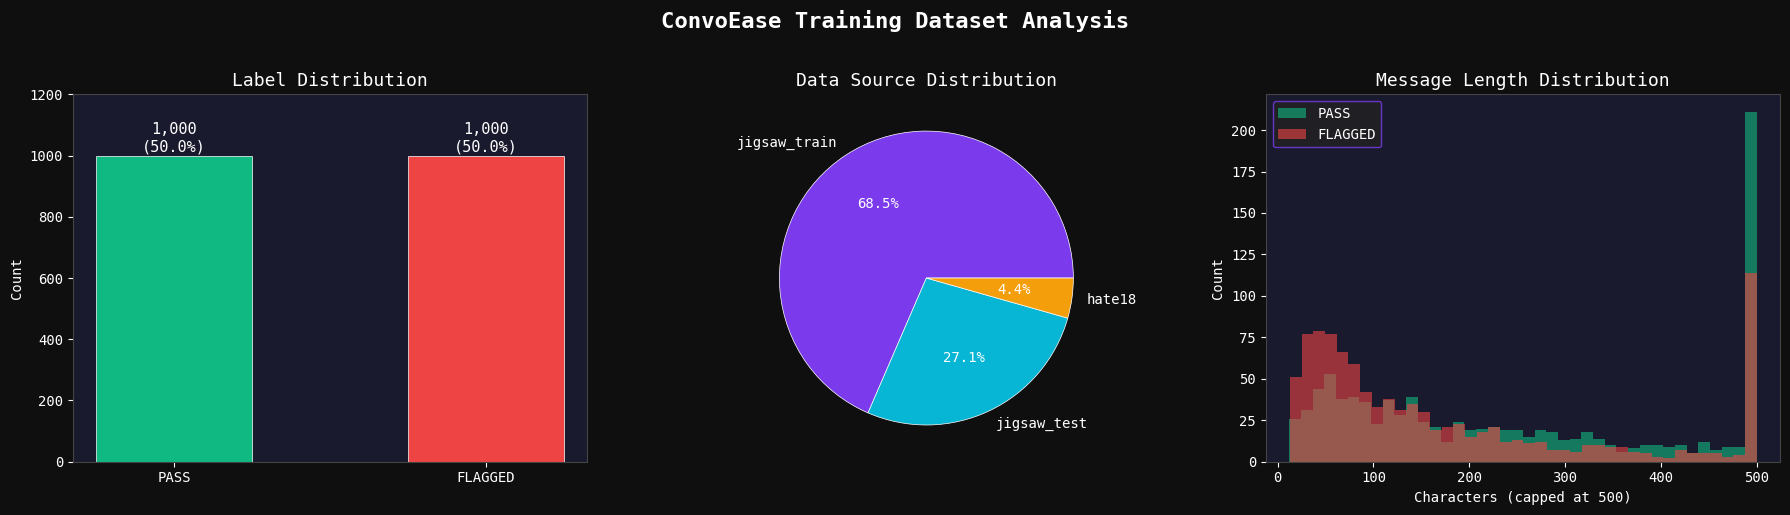

✅ Saved: 01_dataset_analysis.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ConvoEase Training Dataset Analysis", fontsize=16, color="white", fontweight="bold", y=1.02)

# 1. Label distribution
ax = axes[0]
counts = df["label"].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=[GREEN if l == "PASS" else RED for l in counts.index],
              edgecolor="white", linewidth=0.5, width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val:,}\n({val/len(df)*100:.1f}%)",
            ha="center", va="bottom", color="white", fontsize=11)
ax.set_title("Label Distribution", color="white", fontsize=13)
ax.set_ylabel("Count", color="white")
ax.set_ylim(0, counts.max() * 1.2)
ax.tick_params(colors="white")

# 2. Source distribution
ax = axes[1]
src_counts = df["source"].value_counts()
colors = [ACCENT, ACCENT2, YELLOW][:len(src_counts)]
wedges, texts, autotexts = ax.pie(
    src_counts.values, labels=src_counts.index,
    autopct="%1.1f%%", colors=colors,
    textprops={"color": "white", "fontsize": 10},
    wedgeprops={"edgecolor": "white", "linewidth": 0.5}
)
for at in autotexts: at.set_color("white")
ax.set_title("Data Source Distribution", color="white", fontsize=13)

# 3. Message length distribution
ax = axes[2]
df["msg_len"] = df["message"].str.len()
for label, color in [("PASS", GREEN), ("FLAGGED", RED)]:
    subset = df[df["label"] == label]["msg_len"]
    ax.hist(subset.clip(upper=500), bins=40, alpha=0.6,
            color=color, label=label, edgecolor="none")
ax.set_title("Message Length Distribution", color="white", fontsize=13)
ax.set_xlabel("Characters (capped at 500)", color="white")
ax.set_ylabel("Count", color="white")
ax.legend(facecolor="#222", edgecolor=ACCENT, labelcolor="white")

plt.tight_layout()
plt.savefig("/content/01_dataset_analysis.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f0f")
plt.show()
print("✅ Saved: 01_dataset_analysis.png")


## 🤖 Step 8 — Load Phi-3-mini + Apply LoRA
> Downloads ~2.2GB first time, cached after

In [10]:
print(f"Loading {MODEL_NAME} with 4-bit quantization...")
t0 = time.time()

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name       = MODEL_NAME,
    max_seq_length   = MAX_SEQ_LEN,
    dtype            = None,          # auto-detect (bfloat16 on T4)
    load_in_4bit     = LOAD_IN_4BIT,
)

print(f"✅ Model loaded in {time.time()-t0:.0f}s")
print(f"   Parameters: {model.num_parameters():,}")

# Apply LoRA adapters — these are the only weights that get trained
model = FastLanguageModel.get_peft_model(
    model,
    r                   = LORA_R,
    target_modules      = ["q_proj", "k_proj", "v_proj", "o_proj",
                            "gate_proj", "up_proj", "down_proj"],
    lora_alpha          = LORA_ALPHA,
    lora_dropout        = LORA_DROPOUT,
    bias                = "none",
    use_gradient_checkpointing = "unsloth",
    random_state        = RANDOM_SEED,
    use_rslora          = False,
)

# Count trainable vs frozen
total_params    = sum(p.numel() for p in model.parameters())
trainable       = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen          = total_params - trainable

print(f"\n📊 Parameter Summary:")
print(f"   Total params    : {total_params:,}")
print(f"   Trainable (LoRA): {trainable:,}  ({trainable/total_params*100:.2f}%)")
print(f"   Frozen (base)   : {frozen:,}  ({frozen/total_params*100:.2f}%)")
print(f"\n   Only {trainable/total_params*100:.2f}% of the model trains — this is QLoRA efficiency!")

# VRAM usage
if torch.cuda.is_available():
    used  = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"\n🔥 VRAM used: {used:.1f}GB / {total:.1f}GB ({used/total*100:.1f}%)")


Loading unsloth/Phi-3-mini-4k-instruct with 4-bit quantization...
==((====))==  Unsloth 2026.4.1: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/194 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/458 [00:00<?, ?B/s]

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


✅ Model loaded in 42s
   Parameters: 3,821,079,552


Unsloth 2026.4.1 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.



📊 Parameter Summary:
   Total params    : 2,039,024,640
   Trainable (LoRA): 29,884,416  (1.47%)
   Frozen (base)   : 2,009,140,224  (98.53%)

   Only 1.47% of the model trains — this is QLoRA efficiency!

🔥 VRAM used: 2.4GB / 15.6GB (15.3%)


## 📊 Step 9 — Model Architecture Visualization

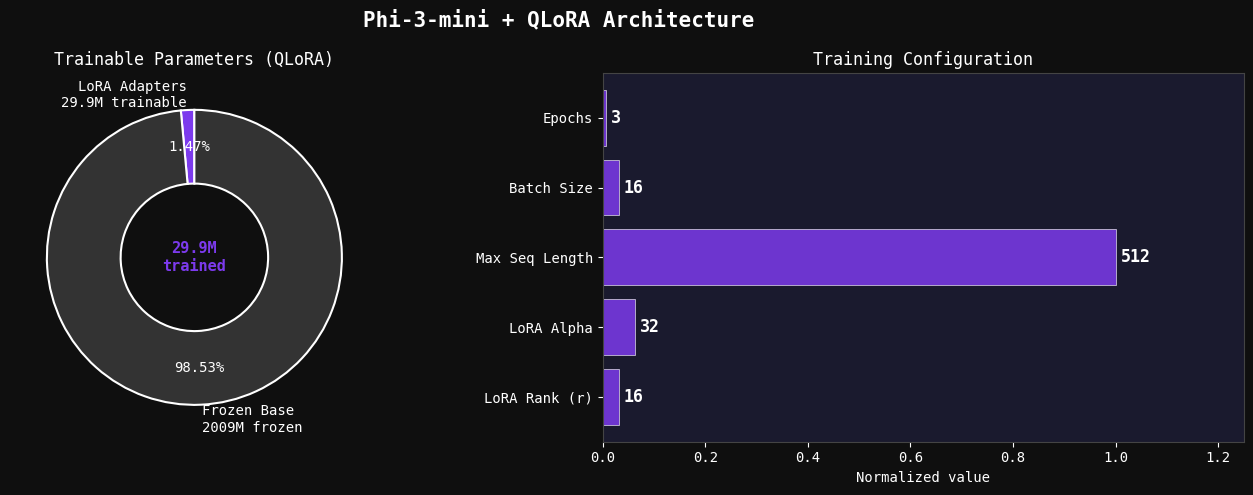

✅ Saved: 02_model_architecture.png


In [11]:
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen       = total_params - trainable

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phi-3-mini + QLoRA Architecture", fontsize=15, color="white", fontweight="bold")

# 1. Trainable vs Frozen donut
ax = axes[0]
sizes  = [trainable, frozen]
colors = [ACCENT, "#333"]
labels = [f"LoRA Adapters\n{trainable/1e6:.1f}M trainable", f"Frozen Base\n{frozen/1e6:.0f}M frozen"]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, autopct="%1.2f%%",
    startangle=90, pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5, "width": 0.5},
    textprops={"color": "white", "fontsize": 10}
)
for at in autotexts: at.set_color("white")
ax.set_title("Trainable Parameters (QLoRA)", color="white", fontsize=12)
ax.text(0, 0, f"{trainable/1e6:.1f}M\ntrained", ha="center", va="center",
        color=ACCENT, fontsize=11, fontweight="bold")

# 2. LoRA config bars
ax = axes[1]
config_names  = ["LoRA Rank (r)", "LoRA Alpha", "Max Seq Length", "Batch Size", "Epochs"]
config_values = [LORA_R, LORA_ALPHA, MAX_SEQ_LEN, BATCH_SIZE * GRAD_ACCUM, NUM_EPOCHS]
norm_values   = [v / max(config_values) for v in config_values]
bars = ax.barh(config_names, norm_values, color=ACCENT, edgecolor="white",
               linewidth=0.5, alpha=0.85)
for bar, val in zip(bars, config_values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            str(val), va="center", color="white", fontsize=12, fontweight="bold")
ax.set_xlim(0, 1.25)
ax.set_title("Training Configuration", color="white", fontsize=12)
ax.set_xlabel("Normalized value", color="white")
ax.tick_params(colors="white")

plt.tight_layout()
plt.savefig("/content/02_model_architecture.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f0f")
plt.show()
print("✅ Saved: 02_model_architecture.png")


## 🚀 Step 10 — Training
> Sit back. Watch the loss go down. Each epoch logged.

In [18]:
from transformers import TrainerCallback
import csv

# ── Custom callback to capture per-step metrics ──────────────────────────────
training_log = []   # will hold {step, loss, eval_loss, epoch, lr}

class MetricsCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            entry = {
                "step":      state.global_step,
                "epoch":     round(state.epoch or 0, 3),
                "loss":      logs.get("loss"),
                "eval_loss": logs.get("eval_loss"),
                "lr":        logs.get("learning_rate"),
            }
            training_log.append(entry)
            # Print live
            parts = [f"step {state.global_step:>4}"]
            if entry["loss"]:      parts.append(f"loss={entry['loss']:.4f}")
            if entry["eval_loss"]: parts.append(f"eval={entry['eval_loss']:.4f}")
            if entry["epoch"]:     parts.append(f"epoch={entry['epoch']:.2f}")
            print("  ".join(parts))

# Calculate warmup steps to avoid deprecation warning
max_steps = (len(train_data) // (BATCH_SIZE * GRAD_ACCUM)) * NUM_EPOCHS
warmup_steps = int(max_steps * WARMUP_RATIO)

# ── Training arguments ────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    warmup_steps                = warmup_steps,
    learning_rate               = LEARNING_RATE,
    lr_scheduler_type           = LR_SCHEDULER,
    fp16                        = not torch.cuda.is_bf16_supported(),
    bf16                        = torch.cuda.is_bf16_supported(),
    logging_steps               = 5,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    report_to                   = "none",
    seed                        = RANDOM_SEED,
    optim                       = "adamw_8bit",
    weight_decay                = 0.01,
)

trainer = SFTTrainer(
    model            = model,
    tokenizer        = tokenizer,
    train_dataset    = train_data,
    eval_dataset     = test_data,
    dataset_text_field = "text",
    max_seq_length   = MAX_SEQ_LEN,
    packing          = False,
    args             = training_args,
    callbacks        = [MetricsCallback()],
)

print("╔══════════════════════════════════════════╗")
print("║  🔥 Training Started                      ║")
print(f"║  Dataset   : {len(train_data):,} train / {len(test_data):,} eval     ║")
print(f"║  Epochs    : {NUM_EPOCHS}                              ║")
print(f"║  Est. time : ~{NUM_EPOCHS * len(train_data) // (BATCH_SIZE * GRAD_ACCUM) // 12} minutes              ║")
print("╚══════════════════════════════════════════╝\n")

train_start = time.time()
train_result = trainer.train()
train_end   = time.time()
train_minutes = (train_end - train_start) / 60

print(f"\n✅ Training complete in {train_minutes:.1f} minutes")
print(f"   Final train loss : {train_result.training_loss:.4f}")
print(f"   Total steps      : {train_result.global_step}")

# Save log to CSV
log_df = pd.DataFrame([r for r in training_log if r["loss"] is not None])
log_df.to_csv("/content/training_log.csv", index=False)
print(f"   Log saved        : /content/training_log.csv  ({len(log_df)} entries)")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1700 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/300 [00:00<?, ? examples/s]

╔══════════════════════════════════════════╗
║  🔥 Training Started                      ║
║  Dataset   : 1,700 train / 300 eval     ║
║  Epochs    : 3                              ║
║  Est. time : ~26 minutes              ║
╚══════════════════════════════════════════╝



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,700 | Num Epochs = 3 | Total steps = 321
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 29,884,416 of 3,850,963,968 (0.78% trained)


Epoch,Training Loss,Validation Loss


OutOfMemoryError: CUDA out of memory. Tried to allocate 32.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 23.81 MiB is free. Including non-PyTorch memory, this process has 14.54 GiB memory in use. Of the allocated memory 13.88 GiB is allocated by PyTorch, and 515.71 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## 📉 Step 11 — Training Loss Curves

In [ ]:
log_df = pd.read_csv("/content/training_log.csv")
train_log = log_df[log_df["loss"].notna()].copy()
eval_log  = log_df[log_df["eval_loss"].notna()].copy()

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor("#0f0f0f")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Train loss over steps ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(train_log["step"], train_log["loss"], color=ACCENT, linewidth=1.5,
         alpha=0.4, label="Step loss")
# Smooth with rolling average
window = max(3, len(train_log)//20)
smooth = train_log["loss"].rolling(window, min_periods=1).mean()
ax1.plot(train_log["step"], smooth, color=ACCENT, linewidth=2.5, label=f"Smoothed (w={window})")
# Epoch markers
epoch_steps = [int(r["step"]) for r in training_log if r.get("eval_loss")]
for i, s in enumerate(epoch_steps, 1):
    ax1.axvline(x=s, color=YELLOW, linestyle="--", alpha=0.6, linewidth=1)
    ax1.text(s+1, ax1.get_ylim()[1]*0.95, f"Epoch {i}", color=YELLOW, fontsize=9)
ax1.set_title("Training Loss — Steps", color="white", fontsize=13, pad=10)
ax1.set_xlabel("Step", color="white")
ax1.set_ylabel("Loss", color="white")
ax1.legend(facecolor="#222", edgecolor=ACCENT, labelcolor="white")
ax1.grid(True)

# ── 2. Eval loss per epoch ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
if len(eval_log) > 0:
    epochs_x = list(range(1, len(eval_log)+1))
    ax2.plot(epochs_x, eval_log["eval_loss"].values, "o-",
             color=ACCENT2, linewidth=2, markersize=8, markerfacecolor="white")
    for x, y in zip(epochs_x, eval_log["eval_loss"].values):
        ax2.text(x, y+0.005, f"{y:.4f}", ha="center", color="white", fontsize=10)
ax2.set_title("Eval Loss per Epoch", color="white", fontsize=13, pad=10)
ax2.set_xlabel("Epoch", color="white")
ax2.set_ylabel("Eval Loss", color="white")
ax2.set_xticks(epochs_x)
ax2.grid(True)

# ── 3. Train vs Eval comparison bar ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
if len(eval_log) > 0:
    labels_bar = [f"Epoch {i}" for i in range(1, len(eval_log)+1)]
    x = np.arange(len(labels_bar))
    # Approximate train loss per epoch
    steps_per_epoch = len(train_log) // NUM_EPOCHS
    train_per_epoch = [
        train_log["loss"].iloc[i*steps_per_epoch:(i+1)*steps_per_epoch].mean()
        for i in range(len(eval_log))
    ]
    w = 0.35
    ax3.bar(x - w/2, train_per_epoch, w, label="Train loss", color=ACCENT, alpha=0.85)
    ax3.bar(x + w/2, eval_log["eval_loss"].values, w, label="Eval loss", color=ACCENT2, alpha=0.85)
    ax3.set_xticks(x)
    ax3.set_xticklabels(labels_bar, color="white")
    ax3.set_title("Train vs Eval Loss per Epoch", color="white", fontsize=12)
    ax3.set_ylabel("Loss", color="white")
    ax3.legend(facecolor="#222", edgecolor="#555", labelcolor="white")
    ax3.grid(True, axis="y")

# ── 4. Learning rate schedule ─────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
lr_log = log_df[log_df["lr"].notna()]
if len(lr_log) > 0:
    ax4.plot(lr_log["step"], lr_log["lr"], color=GREEN, linewidth=2)
    ax4.fill_between(lr_log["step"], lr_log["lr"], alpha=0.2, color=GREEN)
ax4.set_title("Learning Rate Schedule (Cosine)", color="white", fontsize=12)
ax4.set_xlabel("Step", color="white")
ax4.set_ylabel("LR", color="white")
ax4.grid(True)

# ── 5. Loss improvement ───────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
if len(train_log) > 5:
    first5  = train_log["loss"].head(5).mean()
    last5   = train_log["loss"].tail(5).mean()
    pct_imp = (first5 - last5) / first5 * 100
    bars = ax5.bar(["Start\n(first 5 steps)", "End\n(last 5 steps)"],
                   [first5, last5], color=[RED, GREEN], edgecolor="white", linewidth=0.5, width=0.4)
    for bar, val in zip(bars, [first5, last5]):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.4f}", ha="center", color="white", fontsize=13, fontweight="bold")
    ax5.set_title(f"Loss Improvement: {pct_imp:.1f}%", color="white", fontsize=12)
    ax5.set_ylabel("Loss", color="white")
    ax5.grid(True, axis="y")
    ax5.text(0.5, 0.05, f"▼ {pct_imp:.1f}% reduction", transform=ax5.transAxes,
             ha="center", color=GREEN, fontsize=13, fontweight="bold")

fig.suptitle("ConvoEase Fine-Tuning — Training Metrics", fontsize=16,
             color="white", fontweight="bold", y=1.01)
plt.savefig("/content/03_training_curves.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f0f")
plt.show()
print("✅ Saved: 03_training_curves.png")


## 🎯 Step 12 — Model Evaluation on Test Set

In [ ]:
print("Running inference on test set...")
FastLanguageModel.for_inference(model)

model.eval()
predictions = []
ground_truth = []

LABEL_MAP = {"pass": "PASS", "flagged": "FLAGGED"}

def predict_batch(messages, rules_list, contexts_list):
    results = []
    for msg, rules, ctx in zip(messages, rules_list, contexts_list):
        prompt = (
            f"<|user|>\nYou are a strict Group Chat Moderator.\n\n"
            f"ADMIN RULES:\n{rules}\n\n"
            f"CHAT CONTEXT (Last several messages):\n{ctx}\n\n"
            f"YOUR TASK:\nValidate the following NEW message.\n"
            f"NEW MESSAGE: \"{msg}\"\n\n"
            f"OUTPUT FORMAT:\n- If compliant: PASS\n- If violation: FLAGGED <reason><|end|>\n"
            f"<|assistant|>\n"
        )
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
        with torch.no_grad():
            out = model.generate(
                **inputs, max_new_tokens=40,
                do_sample=False, temperature=1.0, repetition_penalty=1.1
            )
        decoded = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
        first_word = decoded.strip().split()[0].lower() if decoded.strip() else "pass"
        results.append("FLAGGED" if "flagged" in first_word else "PASS")
    return results

# Run in batches of 8
test_msgs  = test_df["message"].tolist()
test_rules = test_df["rules"].tolist()
test_ctxs  = test_df["context"].tolist()
test_truth = test_df["label"].tolist()

from tqdm.auto import tqdm
EVAL_BATCH = 8
for i in tqdm(range(0, len(test_df), EVAL_BATCH), desc="Evaluating"):
    batch_preds = predict_batch(
        test_msgs[i:i+EVAL_BATCH],
        test_rules[i:i+EVAL_BATCH],
        test_ctxs[i:i+EVAL_BATCH]
    )
    predictions.extend(batch_preds)
    ground_truth.extend(test_truth[i:i+EVAL_BATCH])

# Metrics
acc  = accuracy_score(ground_truth, predictions)
f1   = f1_score(ground_truth, predictions, pos_label="FLAGGED", average="binary")
prec = precision_score(ground_truth, predictions, pos_label="FLAGGED", average="binary")
rec  = recall_score(ground_truth, predictions, pos_label="FLAGGED", average="binary")

print(f"\n╔══════════════════════════════════════════╗")
print(f"║  📊 Evaluation Results                    ║")
print(f"╠══════════════════════════════════════════╣")
print(f"║  Accuracy   : {acc*100:>6.2f}%                    ║")
print(f"║  F1 Score   : {f1*100:>6.2f}%                    ║")
print(f"║  Precision  : {prec*100:>6.2f}%                    ║")
print(f"║  Recall     : {rec*100:>6.2f}%                    ║")
print(f"╚══════════════════════════════════════════╝")

print("\nDetailed Classification Report:")
print(classification_report(ground_truth, predictions, target_names=["PASS", "FLAGGED"]))

# Save for later
eval_results = {
    "accuracy": acc, "f1": f1, "precision": prec, "recall": rec,
    "predictions": predictions, "ground_truth": ground_truth
}


## 📊 Step 13 — Evaluation Visualizations

In [ ]:
fig = plt.figure(figsize=(20, 10))
fig.patch.set_facecolor("#0f0f0f")
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.4)

# ── 1. Confusion Matrix ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[:, :2])
cm  = confusion_matrix(ground_truth, predictions, labels=["PASS", "FLAGGED"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["PASS", "FLAGGED"],
            yticklabels=["PASS", "FLAGGED"],
            linewidths=2, linecolor="#0f0f0f",
            annot_kws={"size": 18, "weight": "bold", "color": "white"},
            ax=ax1, cbar_kws={"shrink": 0.8})
ax1.set_title("Confusion Matrix", color="white", fontsize=15, pad=15)
ax1.set_xlabel("Predicted", color="white", fontsize=12)
ax1.set_ylabel("Actual", color="white", fontsize=12)
ax1.tick_params(colors="white", labelsize=12)

# Add TP/FP/FN/TN labels
for (row, col), val in np.ndenumerate(cm):
    label = {(0,0):"TN", (0,1):"FP", (1,0):"FN", (1,1):"TP"}[(row,col)]
    ax1.text(col+0.5, row+0.7, label, ha="center",
             color=GREEN if label in ("TP","TN") else RED, fontsize=13, fontweight="bold")

# ── 2. Metrics bar chart ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
metrics_vals   = [acc*100, f1*100, prec*100, rec*100]
metrics_labels = ["Accuracy", "F1 Score", "Precision", "Recall"]
bar_colors     = [ACCENT, ACCENT2, GREEN, YELLOW]
bars = ax2.bar(metrics_labels, metrics_vals, color=bar_colors,
               edgecolor="white", linewidth=0.5, width=0.55)
for bar, val in zip(bars, metrics_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", color="white", fontsize=12, fontweight="bold")
ax2.set_ylim(0, 115)
ax2.set_title("Evaluation Metrics", color="white", fontsize=13)
ax2.set_ylabel("Score (%)", color="white")
ax2.tick_params(colors="white")
ax2.grid(True, axis="y")

# ── 3. Prediction distribution ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 3])
pred_counts = pd.Series(predictions).value_counts()
colors3 = [GREEN if l == "PASS" else RED for l in pred_counts.index]
ax3.bar(pred_counts.index, pred_counts.values, color=colors3,
        edgecolor="white", linewidth=0.5, width=0.4)
for i, (label, cnt) in enumerate(pred_counts.items()):
    ax3.text(i, cnt + 1, f"{cnt}\n({cnt/len(predictions)*100:.1f}%)",
             ha="center", color="white", fontsize=11)
ax3.set_title("Model Predictions Distribution", color="white", fontsize=12)
ax3.set_ylabel("Count", color="white")
ax3.tick_params(colors="white")
ax3.grid(True, axis="y")

# ── 4. Per-class metrics comparison ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2:])
report = classification_report(ground_truth, predictions,
                                target_names=["PASS", "FLAGGED"], output_dict=True)
classes = ["PASS", "FLAGGED"]
metrics_names = ["precision", "recall", "f1-score"]
x = np.arange(len(classes))
w = 0.25
colors_per = [ACCENT, ACCENT2, GREEN]
for i, (metric, color) in enumerate(zip(metrics_names, colors_per)):
    vals = [report[cls][metric]*100 for cls in classes]
    bars = ax4.bar(x + i*w, vals, w, label=metric.capitalize(),
                   color=color, alpha=0.85, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.0f}%", ha="center", color="white", fontsize=10)
ax4.set_title("Per-Class Metrics", color="white", fontsize=13)
ax4.set_xticks(x + w)
ax4.set_xticklabels(classes, color="white", fontsize=12)
ax4.set_ylabel("Score (%)", color="white")
ax4.set_ylim(0, 120)
ax4.legend(facecolor="#222", edgecolor=ACCENT, labelcolor="white")
ax4.grid(True, axis="y")

fig.suptitle("ConvoEase — Model Evaluation Results", fontsize=17,
             color="white", fontweight="bold", y=1.02)
plt.savefig("/content/04_evaluation_results.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f0f")
plt.show()
print("✅ Saved: 04_evaluation_results.png")


## 🧪 Step 14 — Sample Predictions (Qualitative Check)

In [ ]:
# Show 12 interesting predictions: 3 correct PASS, 3 correct FLAGGED,
# 3 false positives, 3 false negatives
results_df = test_df.copy()
results_df["predicted"] = predictions
results_df["correct"]   = results_df["label"] == results_df["predicted"]

correct_pass    = results_df[(results_df["label"]=="PASS")    & (results_df["correct"])].head(3)
correct_flagged = results_df[(results_df["label"]=="FLAGGED") & (results_df["correct"])].head(3)
wrong_fp        = results_df[(results_df["label"]=="PASS")    & (~results_df["correct"])].head(3)
wrong_fn        = results_df[(results_df["label"]=="FLAGGED") & (~results_df["correct"])].head(3)

sample_rows = []
for subset, category in [
    (correct_pass,    "✅ True PASS"),
    (correct_flagged, "✅ True FLAGGED"),
    (wrong_fp,        "⚠️ False Positive"),
    (wrong_fn,        "⚠️ False Negative"),
]:
    for _, row in subset.iterrows():
        sample_rows.append({
            "Category":  category,
            "Message":   row["message"][:80] + ("..." if len(row["message"])>80 else ""),
            "Actual":    row["label"],
            "Predicted": row["predicted"],
        })

sample_display = pd.DataFrame(sample_rows)

# Colorize HTML table
def color_row(row):
    if "False" in row["Category"]:
        bg = "rgba(239,68,68,0.15)"
    else:
        bg = "rgba(16,185,129,0.10)"
    return [f"background-color: {bg}"]*len(row)

styled = sample_display.style.apply(color_row, axis=1)     .set_properties(**{"color":"white", "border":"1px solid #444"})     .set_table_styles([{
        "selector": "th",
        "props": [("background-color","#1a1a2e"),("color",ACCENT),("font-size","12px")]
    }])

display(styled)

# Print summary
total_correct = results_df["correct"].sum()
print(f"\n📊 Quick summary:")
print(f"   Total test samples : {len(results_df)}")
print(f"   Correct predictions: {total_correct} ({total_correct/len(results_df)*100:.1f}%)")
print(f"   False positives    : {((results_df.label=='PASS') & (~results_df.correct)).sum()}")
print(f"   False negatives    : {((results_df.label=='FLAGGED') & (~results_df.correct)).sum()}")


## 🏆 Step 15 — Final Training Summary Card

In [ ]:
fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor("#0a0a0a")
ax.set_facecolor("#0a0a0a")
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis("off")

# Border
from matplotlib.patches import FancyBboxPatch, Rectangle
border = FancyBboxPatch((0.1, 0.1), 15.8, 8.8, boxstyle="round,pad=0.1",
                         linewidth=2, edgecolor=ACCENT, facecolor="#111122")
ax.add_patch(border)

# Header
ax.add_patch(Rectangle((0.1, 7.3), 15.8, 1.6, facecolor=ACCENT, alpha=0.9))
ax.text(8, 8.2, "ConvoEase  |  Fine-Tuning Results", ha="center", va="center",
        fontsize=20, color="white", fontweight="bold")
ax.text(8, 7.6, f"Model: {MODEL_NAME}   |   Method: QLoRA   |   Date: {datetime.now().strftime('%Y-%m-%d')}",
        ha="center", va="center", fontsize=11, color="#ddd")

# Metrics boxes
def metric_box(x, y, label, value, color):
    ax.add_patch(FancyBboxPatch((x, y), 3.4, 1.6, boxstyle="round,pad=0.05",
                                linewidth=1.5, edgecolor=color, facecolor="#1a1a2e"))
    ax.text(x+1.7, y+1.1, value, ha="center", va="center",
            fontsize=22, color=color, fontweight="bold")
    ax.text(x+1.7, y+0.35, label, ha="center", va="center",
            fontsize=11, color="#aaa")

final_loss = log_df[log_df["loss"].notna()]["loss"].iloc[-1] if len(log_df) else 0

metric_box(0.3,  5.4, "Accuracy",      f"{acc*100:.1f}%",   GREEN)
metric_box(3.9,  5.4, "F1 Score",      f"{f1*100:.1f}%",    ACCENT2)
metric_box(7.5,  5.4, "Precision",     f"{prec*100:.1f}%",  ACCENT)
metric_box(11.1, 5.4, "Recall",        f"{rec*100:.1f}%",   YELLOW)

# Config section
ax.text(0.5, 5.1, "Training Configuration", fontsize=13, color=ACCENT, fontweight="bold")
configs = [
    f"Dataset: {len(df):,} rows  ({len(train_data)} train / {len(test_data)} test)",
    f"Base model: {MODEL_NAME}",
    f"Method: QLoRA  |  LoRA rank: {LORA_R}  |  Alpha: {LORA_ALPHA}",
    f"Epochs: {NUM_EPOCHS}  |  LR: {LEARNING_RATE}  |  Batch: {BATCH_SIZE}×{GRAD_ACCUM}={BATCH_SIZE*GRAD_ACCUM}",
    f"Final train loss: {final_loss:.4f}  |  Training time: {train_minutes:.1f} min",
]
for i, cfg in enumerate(configs):
    ax.text(0.6, 4.6 - i*0.45, f"• {cfg}", fontsize=10, color="#ccc")

# Footer
ax.text(8, 0.4, "Generated by ConvoEase Fine-Tuning Pipeline  •  Anthropic Claude",
        ha="center", fontsize=9, color="#666")

plt.tight_layout()
plt.savefig("/content/05_training_summary_card.png", dpi=200, bbox_inches="tight",
            facecolor="#0a0a0a")
plt.show()
print("✅ Saved: 05_training_summary_card.png")


## 💾 Step 16 — Save Model to Google Drive

In [ ]:
print("Saving fine-tuned LoRA adapter...")
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

# Save to Drive for persistence
import shutil
if os.path.exists(DRIVE_SAVE):
    shutil.rmtree(DRIVE_SAVE)
shutil.copytree(OUTPUT_DIR, DRIVE_SAVE)

print(f"✅ Model saved locally : {OUTPUT_DIR}")
print(f"✅ Model saved to Drive: {DRIVE_SAVE}")

# Save all visuals to Drive too
DRIVE_VISUALS = "/content/drive/MyDrive/convoease_training_visuals"
os.makedirs(DRIVE_VISUALS, exist_ok=True)
for fname in ["01_dataset_analysis.png", "02_model_architecture.png",
              "03_training_curves.png", "04_evaluation_results.png",
              "05_training_summary_card.png", "training_log.csv"]:
    src = f"/content/{fname}"
    if os.path.exists(src):
        shutil.copy(src, f"{DRIVE_VISUALS}/{fname}")
        print(f"   Copied {fname} → Drive")

print(f"\n✅ All visuals saved to Drive: {DRIVE_VISUALS}")


## 📦 Step 17 — Export to GGUF (for Local Deployment)
> This lets you run the model locally with `llama-cpp-python`

In [ ]:
print("Exporting to GGUF Q4_K_M format...")
print("(This takes 5–10 minutes)")

GGUF_DIR = "/content/drive/MyDrive/convoease_gguf"
os.makedirs(GGUF_DIR, exist_ok=True)

# Merge LoRA weights into base model, then quantize to GGUF
model.save_pretrained_gguf(
    GGUF_DIR,
    tokenizer,
    quantization_method = "q4_k_m"   # 4-bit — runs on any laptop CPU
)

print(f"\n✅ GGUF model saved to: {GGUF_DIR}")
print("   File: convoease_model-unsloth.Q4_K_M.gguf")
print("\nTo use locally:")
print("  pip install llama-cpp-python")
print("  from llama_cpp import Llama")
print(f'  llm = Llama(model_path="convoease_model-unsloth.Q4_K_M.gguf")')


## 🖼️ Step 18 — View All Generated Visuals

In [ ]:
from IPython.display import Image, display
import ipywidgets as widgets

visuals = [
    ("01_dataset_analysis.png",    "Dataset Analysis"),
    ("02_model_architecture.png",  "Model Architecture"),
    ("03_training_curves.png",     "Training Loss Curves"),
    ("04_evaluation_results.png",  "Evaluation Results"),
    ("05_training_summary_card.png","Final Summary Card"),
]

print("All generated visuals:")
for fname, title in visuals:
    path = f"/content/{fname}"
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"  ✅ {title:<30} ({size:.0f} KB)  →  {path}")
    else:
        print(f"  ❌ {title} — not found")

print("\n=== FINAL SUMMARY ===")
print(f"  Model    : {MODEL_NAME}")
print(f"  Dataset  : {len(df):,} rows")
print(f"  Accuracy : {acc*100:.2f}%")
print(f"  F1 Score : {f1*100:.2f}%")
print(f"  Duration : {train_minutes:.1f} minutes")
print("\n✅ Fine-tuning complete! All visuals saved to Drive.")
